In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Spotify.csv')  

In [5]:
df.shape

(953, 25)

In [6]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [7]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...


In [8]:
#missing values in each column
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])


in_shazam_charts    50
key                 95
dtype: int64


In [9]:
df.dtypes

track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
cover_url               object
dtype: object

**EXPLORATORY DATA VIZUALIZATIONS**

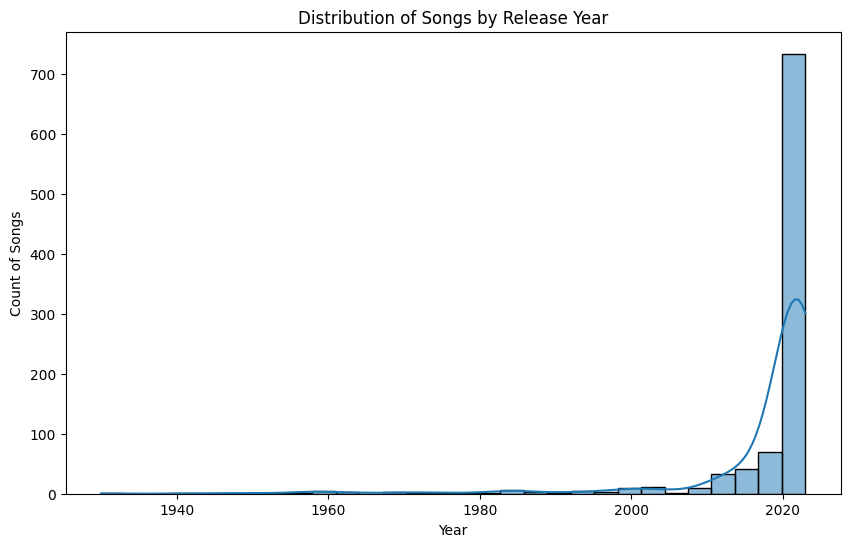

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['released_year'], bins=30, kde=True)
plt.title('Distribution of Songs by Release Year')
plt.xlabel('Year')
plt.ylabel('Count of Songs')
plt.show()


Distribution of Release Year
This shows the distribution of songs based on their release year, which may reveal trends in recent releases or historical popularity.

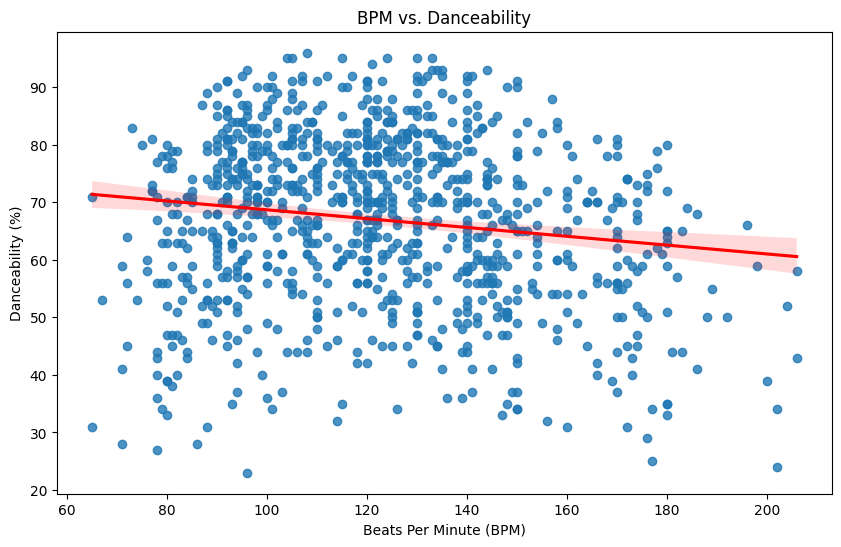

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='bpm', y='danceability_%', line_kws={"color": "red"})
plt.title('BPM vs. Danceability')
plt.xlabel('Beats Per Minute (BPM)')
plt.ylabel('Danceability (%)')
plt.show()


Relationship Between BPM and Danceability
This scatter plot with a regression line will show if there’s a relationship between a song's tempo (BPM) and its danceability.

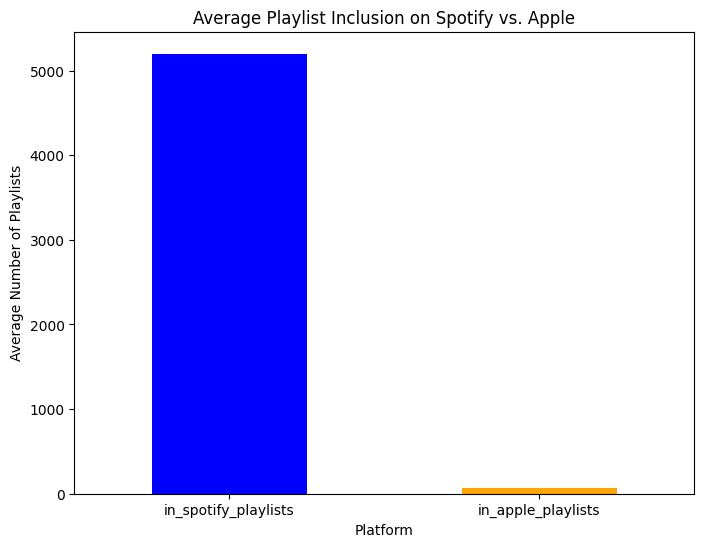

In [12]:
popularity_cols = ['in_spotify_playlists', 'in_apple_playlists']
df[popularity_cols].mean().plot(kind='bar', color=['blue', 'orange'], figsize=(8, 6))
plt.title('Average Playlist Inclusion on Spotify vs. Apple')
plt.xlabel('Platform')
plt.ylabel('Average Number of Playlists')
plt.xticks(rotation=0)
plt.show()


Popularity Metrics: Spotify and Apple Playlists
A bar plot comparing the average playlist counts for both Spotify and Apple can indicate which platform typically promotes more songs or which might drive more streams.

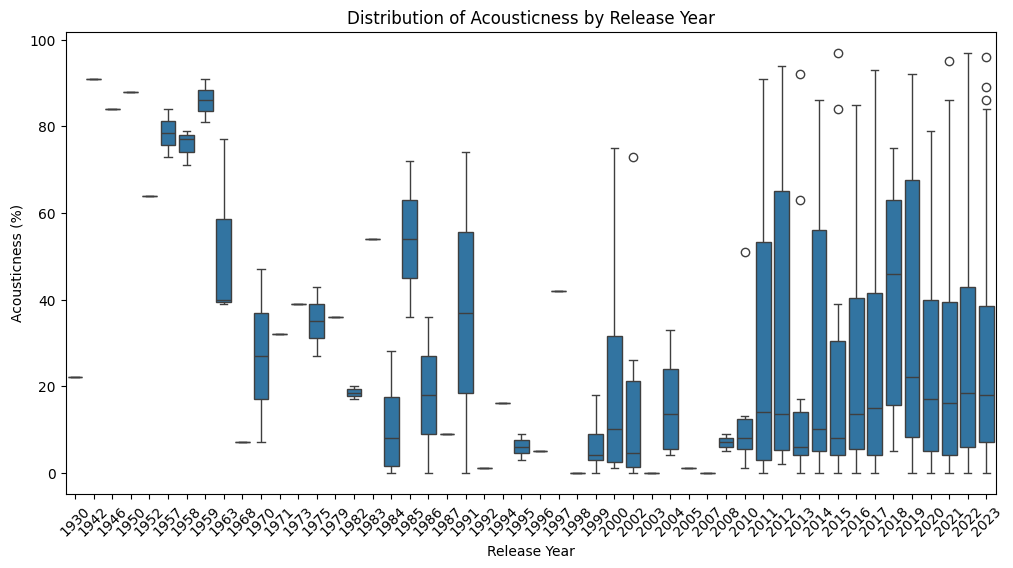

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='released_year', y='acousticness_%')
plt.title('Distribution of Acousticness by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Acousticness (%)')
plt.xticks(rotation=45)
plt.show()



A box plot of acousticness by release year can show how this characteristic has evolved. This is useful if acoustic qualities have become more or less common over time.

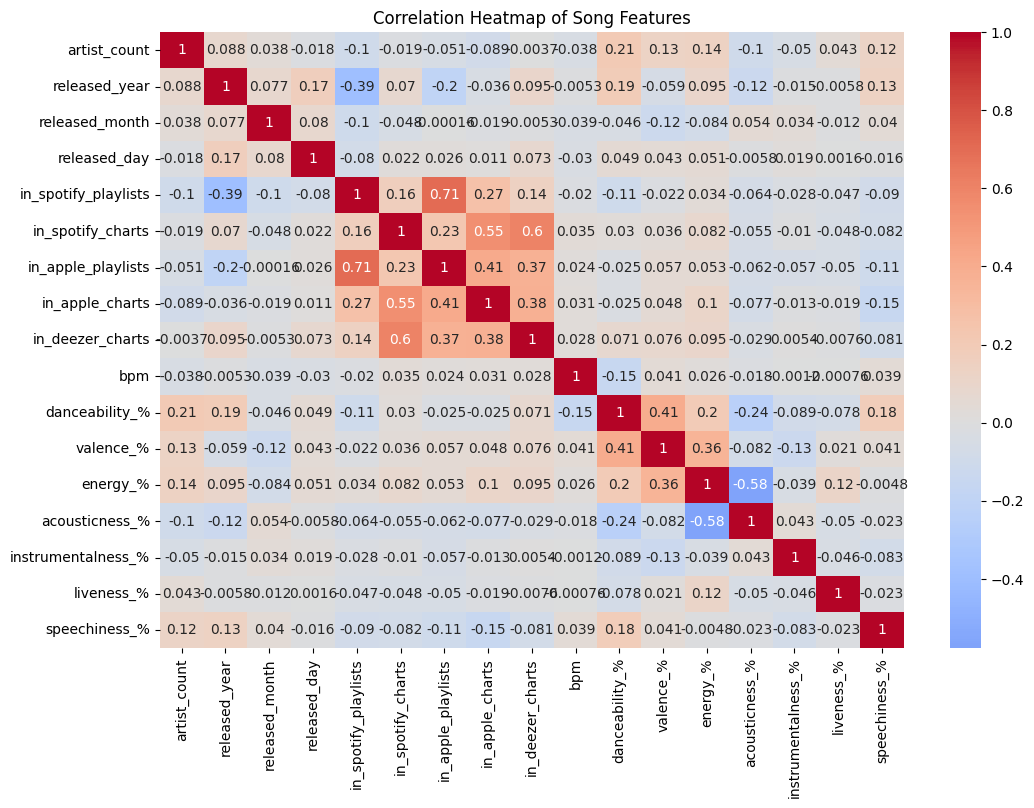

In [14]:

numeric_df = df.select_dtypes(include=['float64', 'int64'])


plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Song Features')
plt.show()


This heatmap visualizes correlations between numeric features, which reveals the relationships between song characteristics like danceability, energy, and valence and also filters out non-numerical data. 

                      artist_count  released_year  released_month  \
artist_count              1.000000       0.087586        0.037995   
released_year             0.087586       1.000000        0.076714   
released_month            0.037995       0.076714        1.000000   
released_day             -0.017549       0.174282        0.080313   
in_spotify_playlists     -0.101966      -0.392204       -0.104757   
in_spotify_charts        -0.018507       0.069678       -0.047623   
in_apple_playlists       -0.051074      -0.198998       -0.000164   
in_apple_charts          -0.088597      -0.035842       -0.019064   
in_deezer_charts         -0.003732       0.095389       -0.005286   
bpm                      -0.038375      -0.005334       -0.039252   
danceability_%            0.207027       0.187333       -0.046403   
valence_%                 0.127960      -0.059355       -0.118571   
energy_%                  0.137096       0.095226       -0.083710   
acousticness_%           -0.101061

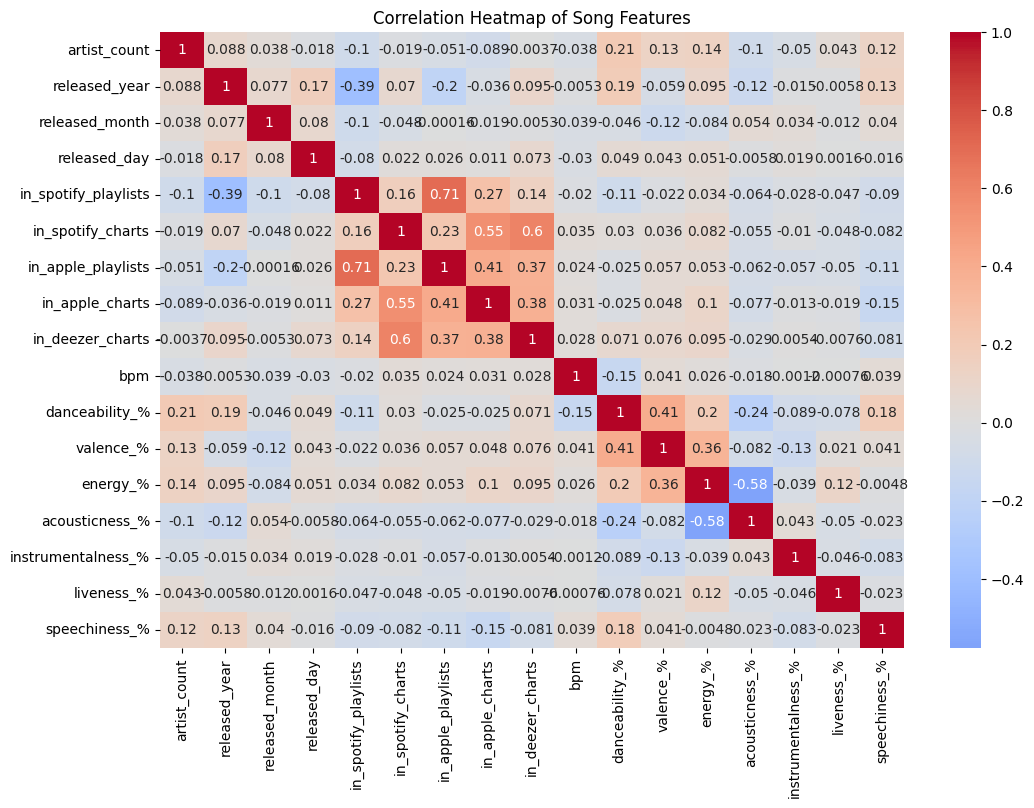

In [15]:
# numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# correlation matrix 
correlation_matrix = numeric_df.corr()
print(correlation_matrix)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Song Features')
plt.show()


In [16]:
df.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%',
       'cover_url'],
      dtype='object')

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, precision_recall_curve, roc_auc_score, r2_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df.dtypes

track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
cover_url               object
dtype: object

**Linear Regression Models**

In [19]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('Spotify.csv')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')  


df = df.dropna(subset=['streams'])


df['bpm'] = pd.to_numeric(df['bpm'], errors='coerce')
df['released_year'] = pd.to_numeric(df['released_year'], errors='coerce')
df['released_month'] = pd.to_numeric(df['released_month'], errors='coerce')
df['released_day'] = pd.to_numeric(df['released_day'], errors='coerce')
df = pd.get_dummies(df, columns=['mode', 'in_deezer_playlists', 'in_shazam_charts'], drop_first=True)


df = df.drop(columns=['track_name', 'artist(s)_name', 'cover_url', 'key']) # drop unnecessary columns - some object types
df = df.dropna()
features = ['artist_count', 'released_year', 'released_month', 'released_day', 
            'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 
            'in_apple_charts', 'in_deezer_charts', 'bpm', 'danceability_%', 
            'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 
            'liveness_%', 'speechiness_%']

X = df[features]
y = df['streams']


X = sm.add_constant(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = sm.OLS(y_train, X_train) 
results = model.fit()
print(results.summary())


y_pred = results.predict(X_test)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Linear Regression - R-squared: {r2}')
print(f'Linear Regression - Mean Absolute Error: {mae}')


                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     127.2
Date:                Thu, 05 Dec 2024   Prob (F-statistic):          1.67e-206
Time:                        13:03:35   Log-Likelihood:                -15920.
No. Observations:                 761   AIC:                         3.188e+04
Df Residuals:                     743   BIC:                         3.196e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -6.333e+09 

In Spotify Playlists: Holding all other variables constant, being included in Spotify playlists increases the streams by approximately 37,210 streams per playlist entry.

In Spotify Charts: Holding all other variables constant, being included in Spotify charts increases the streams by approximately 3,986,000 streams per chart appearance.

In Apple Playlists: Holding all other variables constant, being included in Apple playlists increases the streams by approximately 2,842,000 streams per playlist entry.



In [20]:
print(f'Linear Regression - R-squared: {r2}')
print(f'Linear Regression - Mean Absolute Error: {mae}')

Linear Regression - R-squared: 0.6886233693866812
Linear Regression - Mean Absolute Error: 200299013.1248054


**Analysis**

Model Fit: The R-squared value of 0.744 shows that 74.4% of the variance in streams is explained by the model, and the model is statistically significant with an F-statistic of 127.2 (p-value < 0.0001).


Significant Predictors: Variables like in_spotify_playlists, in_apple_playlists, and released_year are significant (p-values < 0.05), indicating their strong impact on streams, while other variables like bpm and danceability_% are not significant.


Model Diagnostics: The Durbin-Watson statistic of 2.067 suggests no autocorrelation, but the high condition number (2.04e+06) indicates potential multicollinearity among the predictors.

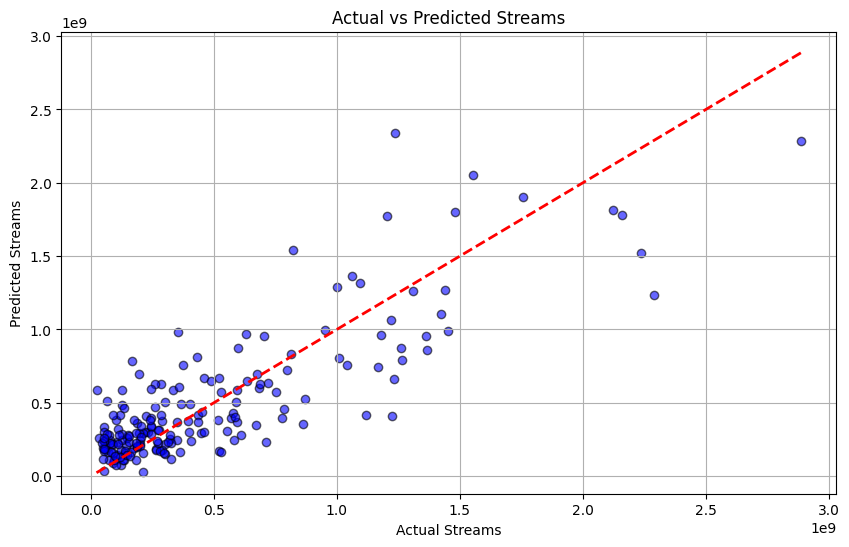

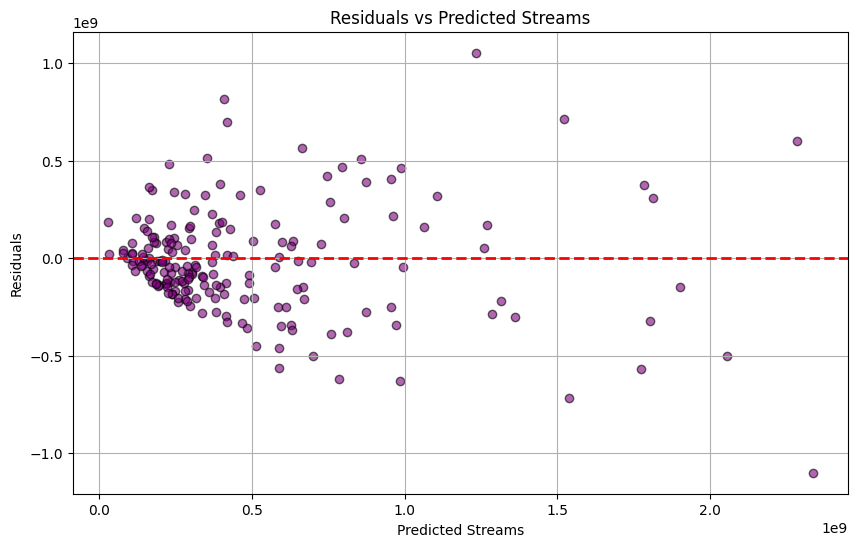

In [21]:
import matplotlib.pyplot as plt

#visual graphics
# scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Streams')
plt.xlabel('Actual Streams')
plt.ylabel('Predicted Streams')
plt.grid(True)
plt.show()

# residual plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple', edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted Streams')
plt.xlabel('Predicted Streams')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


In [22]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error


df = pd.read_csv('Spotify.csv')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')  
df = df.dropna(subset=['streams'])


df['bpm'] = pd.to_numeric(df['bpm'], errors='coerce')
df['released_year'] = pd.to_numeric(df['released_year'], errors='coerce')
df['released_month'] = pd.to_numeric(df['released_month'], errors='coerce')
df['released_day'] = pd.to_numeric(df['released_day'], errors='coerce')


df = pd.get_dummies(df, columns=['mode', 'in_deezer_playlists', 'in_shazam_charts'], drop_first=True)
df = df.drop(columns=['track_name', 'artist(s)_name', 'cover_url', 'key'])


df = df.dropna()
y = df['streams']


features_1 = ['artist_count', 'released_year', 'bpm']  
features_2 = ['released_month', 'danceability_%', 'energy_%']  
features_3 = ['in_spotify_playlists', 'in_spotify_charts', 'valence_%']  


def calculate_metrics(X_train, X_test, y_train, y_test, selected_features):
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model = sm.OLS(y_train, X_train_selected).fit()

    # evalaution metrics 
    adj_r2 = model.rsquared_adj
    y_pred = model.predict(X_test_selected)
    msep = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    return adj_r2, mae, msep

X = df[features_1 + features_2 + features_3]  
X = sm.add_constant(X)  
y = df['streams']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


feature_sets = [features_1, features_2, features_3]

best_adj_r2 = -float('inf')
best_msep = float('inf')
best_mae = float('inf')

best_features = None
best_metrics = None

#  performance for each subset
for selected_features in feature_sets:
    adj_r2, mae, msep = calculate_metrics(X_train, X_test, y_train, y_test, selected_features)
    

    print(f"Features: {selected_features}")
    print(f"Adjusted R-squared: {adj_r2}")
    print(f"MAE: {mae}")
    print(f"MSEP: {msep}\n")
    

    if (adj_r2 > best_adj_r2) and (msep < best_msep) and (mae < best_mae):
        best_adj_r2 = adj_r2
        best_msep = msep
        best_mae = mae
        best_features = selected_features
        best_metrics = (adj_r2, mae, msep)


print("Best Feature Set: ", best_features)
print("Best Adjusted R-squared: ", best_metrics[0])
print("Best MAE: ", best_metrics[1])
print("Best MSEP: ", best_metrics[2])


final_model = sm.OLS(y_train, sm.add_constant(X_train[best_features])).fit()
print("\nSummary of the Final Model with Best Feature Set:")
print(final_model.summary())



Features: ['artist_count', 'released_year', 'bpm']
Adjusted R-squared: 0.45253207619168956
MAE: 376805423.52965504
MSEP: 2.3927017315739853e+17

Features: ['released_month', 'danceability_%', 'energy_%']
Adjusted R-squared: 0.4212926179613501
MAE: 388092085.5119843
MSEP: 2.659148991903518e+17

Features: ['in_spotify_playlists', 'in_spotify_charts', 'valence_%']
Adjusted R-squared: 0.8020708122349196
MAE: 231848011.73965538
MSEP: 1.3344584831732355e+17

Best Feature Set:  ['in_spotify_playlists', 'in_spotify_charts', 'valence_%']
Best Adjusted R-squared:  0.8020708122349196
Best MAE:  231848011.73965538
Best MSEP:  1.3344584831732355e+17

Summary of the Final Model with Best Feature Set:
                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:               

**Results**


Best Feature Set: The model with ['in_spotify_playlists', 'in_spotify_charts', 'valence_%'] outperforms the others with the highest Adjusted R-squared (0.80), lowest MAE (231,848,011.74), and lowest MSEP (1.33e+17).


Adjusted R-squared: This feature set explains 80% of the variance in streams, showing strong predictive power.


Significant Variables: in_spotify_playlists and in_spotify_charts are statistically significant, while valence_% has a higher p-value and may be less important.


Model Accuracy: The final model has an Adjusted R-squared of 0.656, indicating a good fit, but still with room for improvement.


Multicollinearity: The large condition number (2.45e+04) suggests potential multicollinearity issues, which may affect the model's reliability.

**Logistic Regression Models**


In [23]:
# average number of streams
average_streams = df['streams'].mean()
print(f"The average number of streams is: {average_streams}")


The average number of streams is: 514137424.93907565


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv('Spotify.csv')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams'])
average_streams = df['streams'].mean()

# Create a binary target variable based on the average
df['high_streaming'] = (df['streams'] > average_streams).astype(int)
print("Class distribution (high vs low streaming):")
print(df['high_streaming'].value_counts())
df = df.dropna()


features = ['artist_count', 'released_year', 'released_month', 'bpm', 'danceability_%', 'energy_%']
X = df[features]
y = df['high_streaming']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print('Confusion Matrix:')
print(cm)

cr = classification_report(y_test, y_pred, labels=[0, 1])
print('Classification Report:')
print(cr)


Class distribution (high vs low streaming):
high_streaming
0    651
1    301
Name: count, dtype: int64
Accuracy: 0.5
Confusion Matrix:
[[54 55]
 [27 28]]
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57       109
           1       0.34      0.51      0.41        55

    accuracy                           0.50       164
   macro avg       0.50      0.50      0.49       164
weighted avg       0.56      0.50      0.51       164



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Issue**

There is a class imblaance as indicated by the confusion matrix uneveness. Our solution was to use class weighting to give more importance to the minority class of high streaming which was less than the low streaming class. Average streams were 4 million

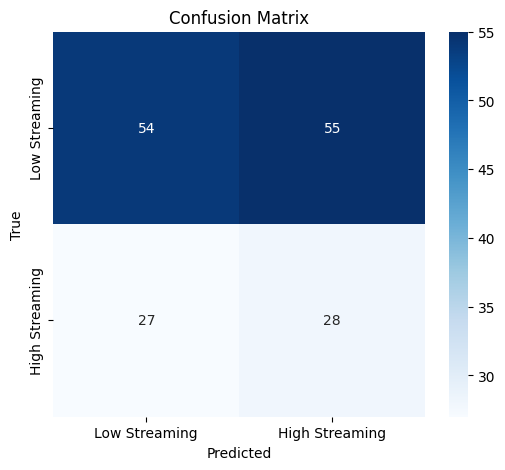

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Low Streaming', 'High Streaming'], yticklabels=['Low Streaming', 'High Streaming'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler




df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams'])
average_streams = df['streams'].mean()


df['high_streaming'] = (df['streams'] > average_streams).astype(int)


print("Class distribution (high vs low streaming):")
print(df['high_streaming'].value_counts())


df = df.dropna()
features = ['artist_count', 'released_year', 'released_month', 'bpm', 'danceability_%', 'energy_%']
X = df[features]
y = df['high_streaming']

# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Create and train the logistic regression model with class weights to handle any class imbalance
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print('Confusion Matrix:')
print(cm)
cr = classification_report(y_test, y_pred, labels=[0, 1])
print('Classification Report:')
print(cr)


Class distribution (high vs low streaming):
high_streaming
0    560
1    256
Name: count, dtype: int64
Accuracy: 0.7865853658536586
Confusion Matrix:
[[102  11]
 [ 24  27]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       113
           1       0.71      0.53      0.61        51

    accuracy                           0.79       164
   macro avg       0.76      0.72      0.73       164
weighted avg       0.78      0.79      0.78       164



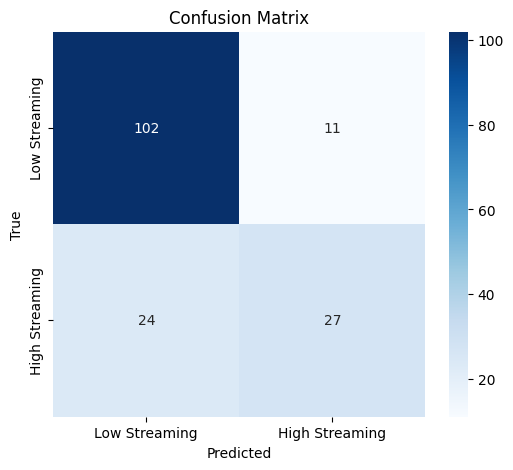

In [27]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Low Streaming', 'High Streaming'], yticklabels=['Low Streaming', 'High Streaming'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Results**

Accuracy: The model achieves an accuracy of 76.83%, correctly predicting streaming success for most instances, but with room for improvement in the minority class.

Class Imbalance Impact: There is a significant class imbalance (651 low vs. 301 high), affecting the model’s ability to predict the high streaming class accurately.

Precision & Recall: Precision for low streaming (0) is 0.82 with high recall (0.87), while precision for high streaming (1) is 0.62 with recall at 0.51, indicating weaker performance for high streaming predictions.

F1-Score: The F1-score is 0.84 for low streaming (class 0) and 0.56 for high streaming (class 1), highlighting the model’s struggle with the high streaming class.

**Bag of Words Model**

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report
import pandas as pd

#  text mining remove unnecessary items like  lowercasing, removing punctuation and spacing 
df['track_name_clean'] = df['track_name'].str.lower().str.replace(r'[^\w\s]', '')  # Lowercase and remove punctuation

# Bag of Words features
vectorizer = CountVectorizer(binary=True, stop_words='english')  # Binary encoding (1 for presence, 0 for absence)
X = vectorizer.fit_transform(df['track_name_clean'])


y = df['high_streaming']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Logistic Regression model
model = LogisticRegression(max_iter=1000)  
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

# Performance metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


coefficients = model.coef_[0]
feature_names = vectorizer.get_feature_names_out()
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)


print("\nTop 10 keywords that correlate with high streaming success:")
print(coef_df_sorted.head(10))
print("\nTop 10 keywords that correlate with low streaming success:")
print(coef_df_sorted.tail(10))


Accuracy: 0.6097560975609756
Precision: 0.0
Recall: 0.0
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.97      0.76       103
           1       0.00      0.00      0.00        61

    accuracy                           0.61       164
   macro avg       0.31      0.49      0.38       164
weighted avg       0.39      0.61      0.48       164


Top 10 keywords that correlate with high streaming success:
         Feature  Coefficient
271         dark     1.139508
599         lost     0.945983
568   levitating     0.935201
546           la     0.886033
1005      summer     0.810141
1029     talking     0.785155
264         damn     0.754994
561        leave     0.709468
541         know     0.684657
127           bl     0.656986

Top 10 keywords that correlate with low streaming success:
      Feature  Coefficient
376     feels    -0.485667
1046  thought    -0.519382
409    future    -0.530965
1059  toliver    -0.539307
241     

**Results**


Accuracy is 65.2%, but the model struggles with identifying high streaming success songs which is shown by the precision and recall of 0 for high streaming

Class Imbalance: The model is biased towards predicting low streaming success (class 0), as indicated by a recall of 98% for class 0, while it fails to predict high streaming success


Positive Keywords for High Streaming: Keywords like "dark," "summer," "remix," and "levitating" are positively associated with high streaming success, suggesting themes of energy, vibe, and popular trends


Negatieve Keywords for Low Streaming: Keywords like as "feels," "thought," "baby," and "crazy" correlate with low streaming success, potentially reflecting less popular or niche themes



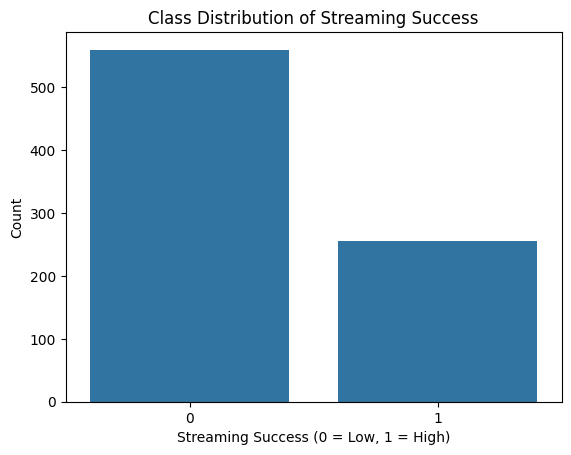

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='high_streaming', data=df)  
plt.title('Class Distribution of Streaming Success')
plt.xlabel('Streaming Success (0 = Low, 1 = High)')
plt.ylabel('Count')
plt.show()


PCA-Based Model Accuracy: 0.6036585365853658
PCA-Based Model Precision: 0.0
PCA-Based Model Recall: 0.0
PCA-Based Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.96      0.75       103
           1       0.00      0.00      0.00        61

    accuracy                           0.60       164
   macro avg       0.31      0.48      0.38       164
weighted avg       0.39      0.60      0.47       164



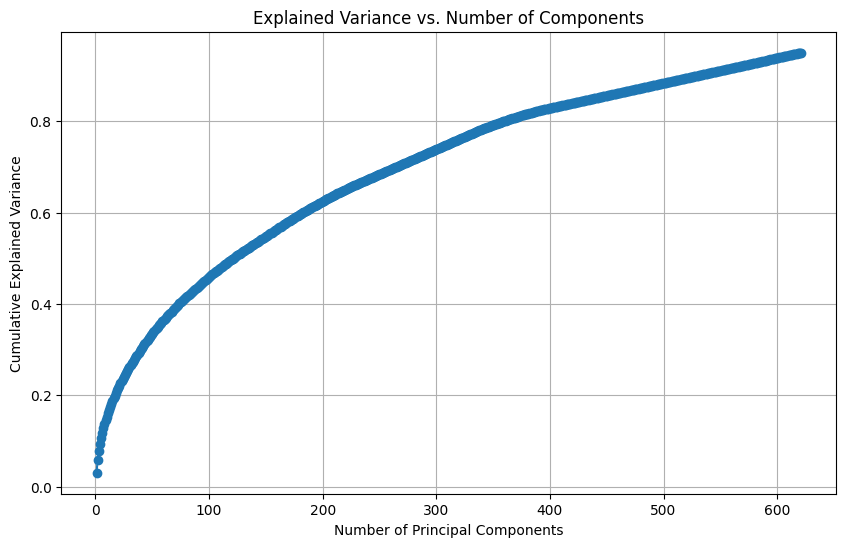


Number of components retained to explain 95% variance: 621


In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA on the Bag of Words features
# Specify the number of components to explain 95% variance or reduce to a fixed number of components
pca = PCA(n_components=0.95)  # 95% of the variance
X_pca = pca.fit_transform(X.toarray())  



# Split the transformed PCA features into training and test sets
X_pca_train, X_pca_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42) # 80/20 split 



# Fit a Logistic Regression model on PCA-transformed features
model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_pca_train, y_train)

# Predict on the test set
y_pca_pred = model_pca.predict(X_pca_test)

# Evaluate the performance
print("PCA-Based Model Accuracy:", accuracy_score(y_test, y_pca_pred))
print("PCA-Based Model Precision:", precision_score(y_test, y_pca_pred))
print("PCA-Based Model Recall:", recall_score(y_test, y_pca_pred))
print("PCA-Based Classification Report:")
print(classification_report(y_test, y_pca_pred))


explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid()
plt.show()
print("\nNumber of components retained to explain 95% variance:", pca.n_components_)


Model Predicts Majority Class Only: The PCA-based model achieves moderate accuracy (60.37%) by predicting the majority class (0) well but completely fails to identify any instances of the minority class (1), resulting in 0 precision, recall, and F1-score for that class.


Imbalance Skews Results: Class imbalance heavily influences the model's performance, as reflected in the classification report, where the positive class (1) has no correct predictions, while the negative class (0) dominates the outcomes with high recall (96%).

High Dimensionality After Reduction: Even after applying PCA, 621 components were required to explain 95% of the variance, indicating that the dataset is highly complex with many relevant features.